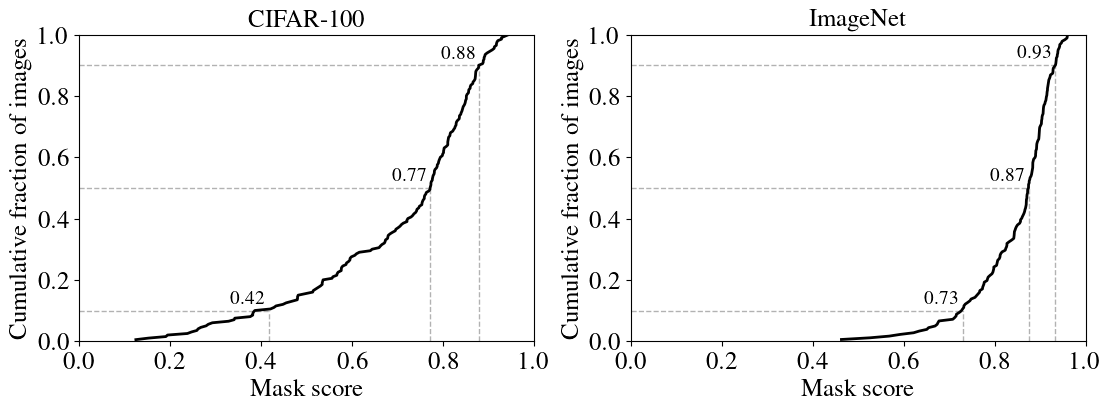

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shutil

LATEX_AVAILABLE = shutil.which("latex") is not None

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "DejaVu Serif"],
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

if LATEX_AVAILABLE:
    plt.rcParams.update({
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
    })
else:
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
    })

label_fs = 18
tick_fs = 18
legend_fs = 15

imagenet_path = "../../results/vggnet16/all_k_vggnet16.csv"
cifar100_path = "../../results/cifar100/cifar100_CSI.csv"

df_imagenet = pd.read_csv(imagenet_path)
df_cifar100 = pd.read_csv(cifar100_path)

image_col = "image"
score_col = "score"

def prepare_scores(df):
    df = df[[image_col, score_col]].dropna()
    df[image_col] = df[image_col].astype(str)
    df = df.drop_duplicates(subset=image_col)
    scores = df[score_col].astype(float).to_numpy()
    scores.sort()
    return scores

scores_im = prepare_scores(df_imagenet)
scores_cf = prepare_scores(df_cifar100)

def plot_ecdf(ax, scores, title):
    n = len(scores)
    y = np.arange(1, n + 1) / n   # cumulative probability

    ax.plot(
        scores, 
        y, 
        linewidth=2.0,
        color="black",)

    qs = [0.10, 0.50, 0.90]
    qvals = np.quantile(scores, qs)

    for q, v in zip(qs, qvals):
        ax.hlines(
            y=q,
            xmin=0.0, xmax=v,
            linestyle="--", linewidth=1.0,
            alpha=0.3, color="black"
        )
        ax.vlines(
            x=v,
            ymin=0.0, ymax=q,
            linestyle="--", linewidth=1.0,
            alpha=0.3, color="black"
        )
        ax.text(v - 0.01, q + 0.01, f"{v:.2f}", fontsize=14, ha="right", va="bottom")

    ax.set_title(title, fontsize=label_fs)
    ax.set_xlabel("Mask score", fontsize=label_fs)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(axis="both", labelsize=tick_fs)

    ax.set_ylabel("Cumulative fraction of images", fontsize=label_fs)

    # ax.grid(linestyle="--", linewidth=0.5, alpha=0.6)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharex=False, sharey=False, constrained_layout=True)

plot_ecdf(axes[1], scores_im, "ImageNet")
plot_ecdf(axes[0], scores_cf, "CIFAR-100")

fig.savefig("masking_scores_ecdf_imagenet_vs_cifar100.pdf", bbox_inches="tight")
plt.show()